# Systemy uczące się - Zad. dom. 2: Naiwny klassyfikator Bayesa

### Autor rozwiązania
Uzupełnij poniższe informacje umieszczając swoje imię i nazwisko oraz numer indeksu:


In [73]:
NAME = "Jan Nowakowski"
ID = "155042"

Ten notebook zawiera dwa zadania związane z klasyfikatorem naiwnego Bayesa, oprócz implementacji zawiera on równie pytania na które trzeba odpowiedzieć.

## Zadanie 1
Zadanie polega na implementacji klasyfikatora naiwnego Bayesa dla zmiennych ciągłych gdzie za rozkłady cechy przyjmij rozkłady normalne.

In [74]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

plt.style.use("ggplot")

Do testowania twojego rozwiązania użyj trzech generatorów danych sztucznych `generate1`, `generate2` oraz `generate3` (funkcje te przyjmują jako argument liczbę elementów do wygenerowania z każdej klasy - domyślnie $N=100$). Sposób ich wywołania jest przedstawiony poniżej:

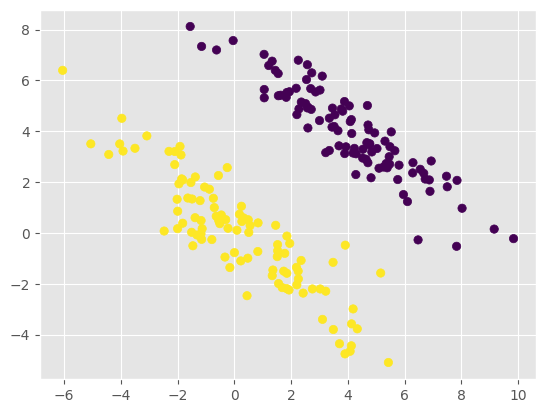

In [87]:
from helpers import generate1, generate2, generate3  # noqa

x, y = generate2()
plt.scatter(x[:, 0], x[:, 1], c=y)

W implementacji będzie przydatna klasa `norm` z pakietu `scipy`, która zwraca wartości funkcji gęstości prawdopodobieństwa rozkładu normalnego dla zmiennych ciągłych.

In [88]:
from scipy.stats import norm

# (x, mean, std)
norm.pdf(5, 0, 1)  # gęstość prawd. dla 5 z rozkładu standardowego
norm.logpdf(5, 0, 1)  # logarytm gęstości prawd. dla 5 z rozkładu standardowego

np.float64(-13.418938533204672)

Zaimplementuj klasyfikator naiwnego Bayesa dla zmiennych ciągłych. Pamiętaj o zabezpieczniu się przed problemem wynikającym z mnożenia wielu małych liczb (prawdopodobieństw).

In [ ]:
class GaussianNaiveBayes():
    def __init__(self) -> None:
        self.means = {}
        # Słownik, który docelowo powinien zawierać tablicę/wektor warunkowych średnich dla każdego atrybutu 
        # Każda tablica/wektor powinna być typu np.array
        # np. 1) means[1] powinno zawierać wektor średnich wartości atrybutów  dla klasy o indeksie 1
        #     2) means[0][1] powinno zawierać średnią 1 atrybutu dla klasy o indeksie 0
        # (Możesz spróbować zaimplementować efektywniejszą implementację używając macierzy)
        self.stds = {}
        # Analogiczna struktura dla odchyleń standardowych
        self.class_log_prob = None
        # Wektor zawierający logarytmy prawdopodobieństwa dla każdej z klas 
        # np. class_log_prob[1] zawiera logarytm prawdopodobieństwa, że klasa jest równa 1 P(C=1)

    def fit(self, x: np.ndarray, y: np.ndarray) -> None:
        #inicjalizacja słowników na logarytmy prawdopodobieństw
        self.class_log_prob = np.zeros(2)
        #iteracja po klasach (0 i 1) w celu obliczenia średnich, odchyleń standardowych i logarytmów prawdopodobieństw dla każdej z klas
        for c in [0, 1]:
            x_c = x[y == c]
            self.means[c] = np.mean(x_c, axis=0)
            self.stds[c] = np.std(x_c, axis=0) + 1e-9  # Dodane 1e-9 zapobiega dzieleniu przez zero
            self.class_log_prob[c] = np.log(len(x_c) / len(x))
        pass

    def predict_proba(self, x: np.ndarray) -> np.ndarray:
        # Inicjalizacja macierzy na logarytmy prawdopodobieństw dla obu klas
        log_cech = np.zeros((x.shape[0], 2))
        
        for c in [0, 1]:
            mean = self.means[c]
            std = self.stds[c]
            log_klas = self.class_log_prob[c]
            # Wzór na logarytm gęstości rozkładu normalnego (Gaussa) dla każdej cechy
            log_pdf = -0.5 * np.log(2 * np.pi * std**2) - 0.5 * ((x - mean) / std)**2
            # sumujemy logarytmy poszczególnych cech i dodajemy logarytm prawdopodobieństwa klasy
            log_cech[:, c] = log_klas + np.sum(log_pdf, axis=1)
            
        # Zabezpieczenie przed przepełnieniem pamięciowym podczas obliczania
        max_log = np.max(log_cech, axis=1, keepdims=True)
        exp_post = np.exp(log_cech - max_log)
        
        # Normalizacja wyników tak, aby szanse dla klas sumowały się do 1 (100%)
        prob = exp_post / np.sum(exp_post, axis=1, keepdims=True)
        
        return prob

    def predict(self, x: np.ndarray) -> np.ndarray:
        # Gotowa funkcja wybierająca klasę z największym prawdopodobieństwem
        prob = self.predict_proba(x)
        return np.argmax(prob, axis=1)


Przetestuj twój klasyfikator na wygenerowanych wcześniej danych.

In [90]:
gnb = GaussianNaiveBayes()
gnb.fit(x, y)

# Trafność na zbiorze uczącym
np.mean(gnb.predict(x) == y)

np.float64(1.0)

Narysowanie nauczonego klasyfikatora

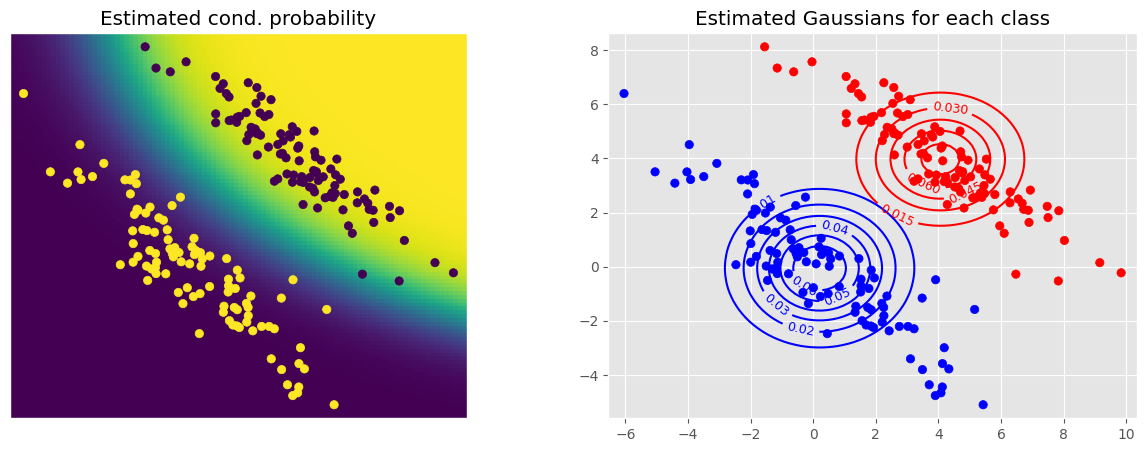

In [91]:
from helpers import plot_gaussian_bayes

plot_gaussian_bayes(x, y, gnb)

Użyj funkcji do generowania danych, aby wygenerować zbiór testowy oraz sprawdź na nim trafność klasyfikacji metody.

In [80]:
x_test, y_test = generate1(1000)
np.mean(gnb.predict(x_test) == y_test)

np.float64(0.993)

**Ćwiczenia**
 - Pamiętaj o przetestowaniu Twojego algorytmu dla wszystkich trzech generatorów danych. W których ze zbiorów założenie o warunkowej niezależności zmiennych jest spełnione? Jak brak spełnienia tego założenia wpływa na działanie klasyfikatora?
 - Z pliku `helpers` zaimportuj klasę `GaussianBayes` (identyczna obsługa jak tej zaimplementowanej przez Ciebie). Klasa implementuje algorytm Bayesa bez założenia o niezależności zmiennych (ale z założeniem o normalności rozkładów). Porównaj wyniki - szczególnie dla zbiorów dla których założenie o warunkowej niezależności zmiennych nie jest spełnione.
 - Klasyfikatora `GaussianBayes` nie można wytrenować na zbiorach które mają mniej niż 3 przykłady dla każdej z klas. Jak myślisz dlaczego? Jak ten problem będzie się zmieniał dla zbiorów o wysokiej liczbie cech?
 - Nawet używając klasyfikatora `GaussianBayes`, który zakłada kompletny model zależności i prawidłowy rozkład danych (nasze dane są generowane z rozkładów normalnych) - często nie jest w stanie uzyskać 100% trafności nawet na zbiorze uczącym. Jak myślisz, dlaczego? 
 - Czy gdyby przepisać do klasyfikatora prawdziwe wartości średnich i macierz wariancji-kowariancji cech (z generatora) - uzyskalibyśmy 100% trafność? Co możemy powiedzieć o takim klasyfikatorze? Czy jest możliwe uzyskanie klasyfikatora bardziej trafnego niż taki? 
 
 Odpowiedzi na dwa ostatnie pytania zostaną sprawdzone: wpisz swoje odpowiedzi poniżej.

-Założenie o warunkowje niezależności zmiennych jest spełnione w zbiorze 1, z w zbiorach 2 i 3 brak spełnienia tego założenia powoduje rozciąganie się zbiorów, oraz w przypadku 3 nachodzenie na siebie klas.

-Jeżeli mamy 3 punktu jesteśmy w stanie utworzyć na nich rozkład prawdopodobieństwa który nie jest płaski w jednym wymiarze, dzięki czemu wyznaczniki macierzy kowariancji będą różne od zera, przy większej ilości cech do poprawnego działąnia wymagana jest większa liczba przykładów niż cech, aby zapewnić pełnowymiarowosć macierzy kowariancji

-W przypadku nachodzenia się na siebie klas klasyfikator nie jest w stanie nauczyć się ich poprawnie rozpoznawać w wyniku czego dla niektórych danych niemożliwe będzie osiągniecie 100% dokładności 

-Ponownie w przypadku nakładania się na siebie klas jest prawdopodobienstwo, że w miejscu gdzie oczekujemy z 80% klasy x znajduje się ogon klasy y i w konsekwencji popełniany zostaje błąd klasyfikacji dla rozkładów klas pokrywających się ze sobą

# Zadanie 2
Klasyfikator naiwnego Bayesa często jest używany do klasyfikacji tekstów. Przetestuj działanie algorytmów na podanym rzeczywistym zbiorze danych: 
> The 20 newsgroups dataset comprises around 18000 newsgroups posts on 20 topics split in two subsets: one for training (or development) and the other one for testing (or for performance evaluation). The split between the train and test set is based upon a messages posted before and after a specific date.

Podany zbiór jest wieloklasowy, więc poniższy kod wybiera z niego podzbiór postów tylko z dwóch tematów.

In [81]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

categories = ['comp.graphics', 'sci.space']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

vectorizer = TfidfVectorizer(binary=True, use_idf=False, norm=None)  # Przekształcenie tekstu na cechy binarne
vectors = vectorizer.fit_transform(newsgroups_train.data)
vectors_test = vectorizer.transform(newsgroups_test.data)
vectors = vectors.toarray()
vectors_test = vectors_test.toarray()

Dokumenty w zbiorze można wyświetlić w następujący sposób.

In [82]:
newsgroups_train.data[0:3]

['From: ab@nova.cc.purdue.edu (Allen B)\nSubject: Re: thining algorithm\nOrganization: Purdue University\nLines: 15\n\nIn article <1q7615INNmi@shelley.u.washington.edu> kshin@stein.u.washington.edu  \n(Kevin Shin) writes:\n> I am trying obtain program to preprocess handwriting characters.\n> Like thining algorithm, graph alogrithm.\n> Do anyone know where I can obtain those?\n\nI usually use "Algorithms for graphics and image processing" by\nTheodosios Pavlidis, but other people here got them same idea and now\n3 of 4 copies in the libraries have been stolen!\n\nAnother reference is "Digital Image Processing" by Gonzalez and\nWintz/Wood, which is widely available but a little expensive ($55\nhere- I just checked today).\n\nab\n',
 "From: stephens@geod.emr.ca (Dave Stephenson)\nSubject: Re: Clementine Science Team Selected\nNntp-Posting-Host: ngis.geod.emr.ca\nOrganization: Dept. of Energy, Mines, and Resources, Ottawa\nLines: 32\n\nnickh@CS.CMU.EDU (Nick Haines) writes:\n\n>In article 

Analogicznie możemy uzyskać dostęp do informacji o klasach.

In [83]:
newsgroups_train.target[0:3]

array([0, 1, 0])

i do "zbinaryzowanego" tekstu

In [84]:
vectors[0:3]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 23882))

Wytrenuj klasyfikator Naiwnego Bayesa z rozmywaniem estymat (patrz pakiet `sklearn`) i sprawdż jego trafność na zbiorze uczącym i testowym.

In [93]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Inicjalizacja klasyfikatora z rozmywaniem estymat
model = MultinomialNB(alpha=1.0)

# Trenowanie na zbiorze uczącym
model.fit(vectors, newsgroups_train.target)

#predykcje i sprawdzenie dokłądności na zbiorze uczącym
train_predictions = model.predict(vectors)
train_accuracy = accuracy_score(newsgroups_train.target, train_predictions)
print(f"Zbiór uczący: {train_accuracy * 100:.2f}%")

# Predykcje i sprawdzenie dokłądności  na zbiorze testowym
test_predictions = model.predict(vectors_test)
test_accuracy = accuracy_score(newsgroups_test.target, test_predictions)
print(f"Zbiór testowy: {test_accuracy * 100:.2f}%")

Zbiór uczący: 99.58%
Zbiór testowy: 96.17%


**Ćwiczenia**
 - Dlaczego klasyfikator Naiwnego Bayesa dość dobrze sprawdza się do powyższego zadania i analogicznych?
 - Przeanalizuj wartości estymat prawdopodobieństw. Które cechy/słowa są najlepszymi wskaźnikami dla podanych klas? Jakie słowa bardzo słabo wskazują na którąkolwiek z klas?
 - Czy byłoby możliwe wytrenowanie równie skutecznego klasyfikatora z mniejszą liczbą cech? W jaki sposób można by to uzyskać?
 - Analizowany zbiór jest oryginalnie wieloklasowy z tego powodu możemy go wykorzystać do wielu testów wybierając różne pary klas. Pełna lista tematów: 'alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc'
 - Czy są pary tematów dla których ten klasyfikator działa znacząco gorzej?
 - Jakie są zalety stosowania klasyfikatora Bayesa dla tego problemu (i w ogólności)? Czy do tego problemu sprawdziłyby się reguły lub drzewa decyzyjne? Dlaczego?
 
 Odpowiedzi na kropki 1, 3 i 6 wpisz poniżej - zostaną sprawdzone.

1 Jest dosyć prosty więc cięzko jest go przeuczyć, oraz odporny na szum który mogą generować nie do końca pasujące do wypowiedzi słowa, równocześnie pomimo że słowa nie są niezależne od siebie to w tekstach występuje dużo kluczowych słów które pozwalają na dosyć pewne rozróżnienie klas
3 można pozbyć się łączników ze zdań typu "w" "i" itp, lub usunąć słowa występujące w każdej klasie w podobnej ilości
6 szybko się trenuje, potrzebuje dosyć mało danych, odporny na szum , do drzew decyzyjnych potrzeba dużo więcej danych